# Description
Calculation of the number of passes using real breadcrumbs. Finished on May 18th, 2026. It is the first version it can count by boundary cell. The grid is done by rectangles

In [16]:
%load_ext autoreload
%autoreload 2
%reset -f
%matplotlib widget

/home/sandbox/personal-repos/Challenge_MultiplePassDetection/PandasAccesor/r2/NOP.py:18: UserWarning: registration of accessor <class 'NOP.NOPAccessor'> under name 'nop' for type <class 'pandas.core.frame.DataFrame'> is overriding a preexisting attribute with the same name.
  class NOPAccessor:


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [17]:
from locallib.picarrodb import *
from locallib.query import *
from locallib.box import *
from locallib.query import *

from NOP import *


# Configuration

# Query the surveys

In [18]:
a = get_reports('Cadent',years = [2026]).execute([EU2_Conn])
report_bc = a.iloc[[700]].copy()
report_bc.db.set_query(query_Segments_byReport(report_table = '#TempReport'))
segments = report_bc.db.execute([EU2_Conn], source_col = 'ReportId', temp_table_name = '#TempReport')

l = 0
surveys = segments['SurveyId'].unique()
#survey = segments[segments['SurveyId'] == surveys[l]]
survey = segments
survey['Breadcrumb_wkt'] = survey['Breadcrumb'].apply(wkt.loads)
survey['geometry'] = survey['Breadcrumb_wkt']
survey_gdf = gpd.GeoDataFrame(survey, geometry = 'geometry', crs = 'EPSG:4326')
utm_crs = survey_gdf.estimate_utm_crs()
survey_gdf = survey_gdf.to_crs(utm_crs)
survey_gdf.set_geometry('geometry', inplace=True)


# Algorithm starts here
## Prepare the surveys

In [19]:
survey_gdf.nop.prepare_survey_gdf()

Center of the bounds: POINT (656871.690735 5939083.0724100005)


In [20]:
survey_gdf.nop.generate_grid()
net = survey_gdf.nop.create_network()

Processing angle:  0
Processing angle:  -10.0
Processing angle:  -20.0
Processing angle:  -30.0
Processing angle:  -40.0
Processing angle:  -50.0
Processing angle:  -60.0
Processing angle:  -70.0
Processing angle:  -80.0
Processing angle:  -90.0
Processing angle:  -100.0
Processing angle:  -110.0
Processing angle:  -120.0
Processing angle:  -130.0
Processing angle:  -140.0
Processing angle:  -150.0
Processing angle:  -160.0
Processing angle:  -170.0
Processing angle:  -180.0
Total boundaries: 3889
Boundaries with no NaN 'nop': 3857
Boundaries after length and spread filters: 3257
Boundaries after removing overlaps: 2775
Boundaries after removing close together cells: 2665
2665 splitters -> 2613 cells
Created network with 2613 nodes and 2881 edges.


<Axes: >

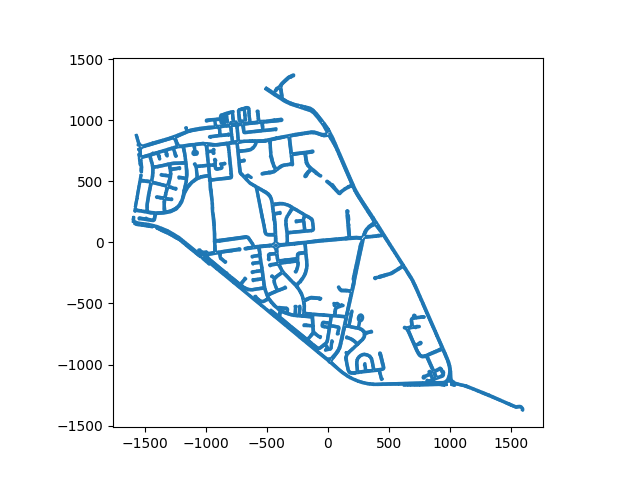

In [21]:
survey_gdf.nop.cell_gdf.boundary.plot()